<a href="https://colab.research.google.com/github/fadelhandiyono/Praktikum-Deret-Waktu-2026/blob/main/Tugas_Praktikum_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [2]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1056)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 + 56
beta0 = 10*56
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


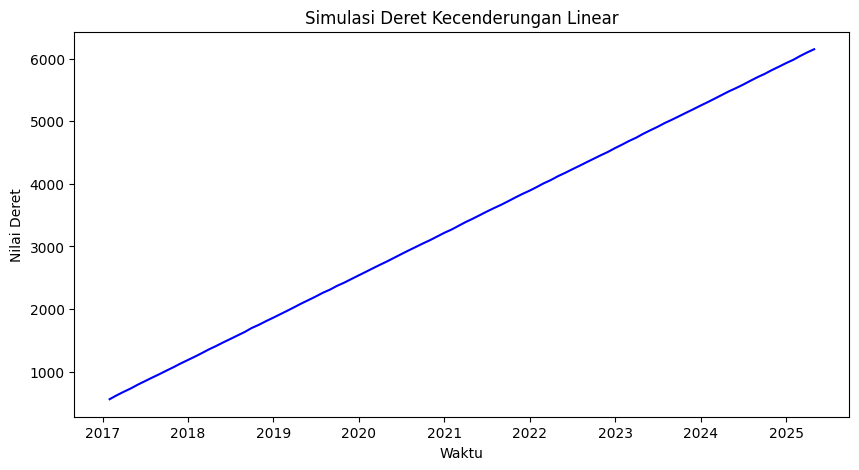

In [3]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

-> Dari plot tersebut dapat dilihat terdapat hubungan linear yang sangat kuat antara waktu dan nilai deret. Nilai korelasi sebesar 1.0000 menunjukkan bahwa nilai deret meningkat hampir secara sempurna seiring bertambahnya waktu. Hasil ini juga terutama menunjukkan adanya kecenderungan linear yang sangat kuat.

In [4]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.725e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.20e-284
Time:                        13:10:34   Log-Likelihood:                -217.69
No. Observations:                 100   AIC:                             439.4
Df Residuals:                      98   BIC:                             444.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          559.8096      0.428   1308.228   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

-> Hasil estimasi parameter sangat dekat dengan parameter yang digunakan. Intercept yang diperoleh sebesar 559.8096, sedangkan nilai sebenarnya adalah 560. Koefisien waktu sebesar 56.5050, sangat dekat dengan nilai sebenarnya yaitu 56.5. Perbedaan kecil tersebut berasal dari noise acak yang ditambahkan ke data. Jadi, model regresi berhasil mengestimasi pola linear yang digunakan untuk membangkitkan data dengan cukup akurat. Nilai $(R^2)$ yang ditampilkan sebesar 1.000, hal ini menunjukkan bahwa variasi data sangat didominasi oleh komponen tren linear.

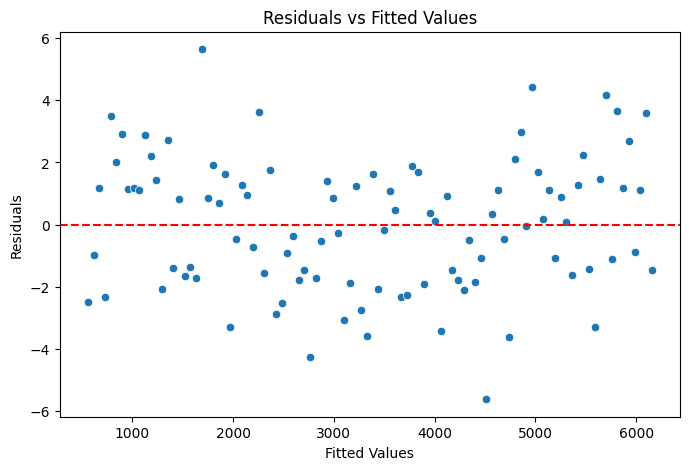

In [6]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

-> Plot menunjukkan residual tersebar di sekitar garis nol, tanpa pola melengkung atau pola kipas yang jelas. Residual tersebar di sekitar nilai nol dan tidak menunjukkan pola sistematis terhadap nilai fitted. Penyebaran residual juga relatif seragam pada berbagai tingkat fitted value. Hal ini menunjukkan bahwa model linear telah menangkap pola utama dalam data dengan cukup baik dan tidak terdapat indikasi visual yang kuat mengenai ketidakkonstanan varians residual.

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.7965


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

-> Hipotesis nol pada uji Breusch-Pagan menyatakan bahwa varians residual konstan dengan nilai taraf signifikansi 0.7965 > 0.05, maka $H_0$ ditolak yang berarti tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas. Dengan demikian asumsi homoskedastisitas dapat dianggap terpenuhi.  

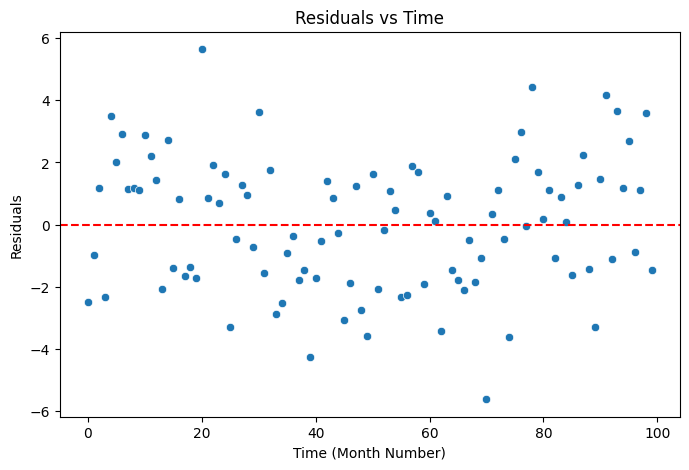

In [8]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

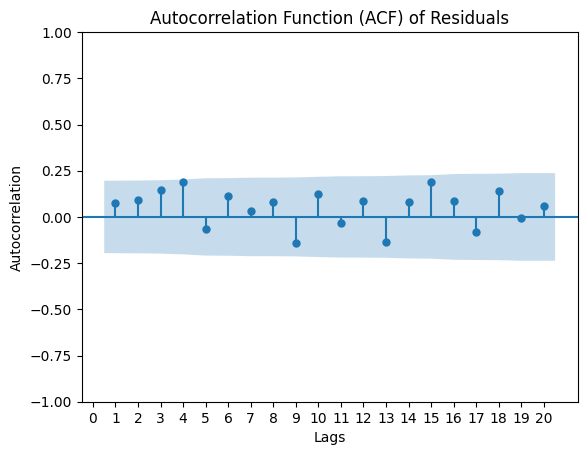

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

-> Plot residual terhadap waktu menunjukkan bahwa residual berfluktuasi di sekitar nol dan tidak memperlihatkan pola tertentu atau tren yang sistematis. Pada plot ACF, sebagian besar nilai autokorelasi residual berada dalam batas interval kepercayaan. Meskipun terdapat beberapa fluktuasi pada lag tertentu, tidak terlihat pola autokorelasi yang kuat dan konsisten. Dengan demikian, secara visual residual cenderung tidak memiliki autokorelasi yang berarti.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.551643   0.457647
2    1.413375   0.493275
3    3.578598   0.310710
4    7.394651   0.116445
5    7.846638   0.164893
6    9.290764   0.157874
7    9.388751   0.225937
8   10.132923   0.255820
9   12.337833   0.194927
10  14.006401   0.172700
11  14.131300   0.225813
12  14.985376   0.242237
13  17.178769   0.191260
14  17.990149   0.207230
15  22.374942   0.098343
16  23.234625   0.107605
17  24.013008   0.119082
18  26.398627   0.090987
19  26.401646   0.119381


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

-> Uji Ljung-Box menguji apakah terdapat autokorelasi residual secara keseluruhan sampai lag tertentu. Karena seluruh p-value yang diperoleh lebih besar dari 0.05, maka $H_0$ gagal ditolak. Dengan demikian, tidak terdapat bukti yang cukup bahwa residual memiliki autokorelasi yang signifikan pada lag yang diuji. Hasil ini konsisten dengan plot ACF.

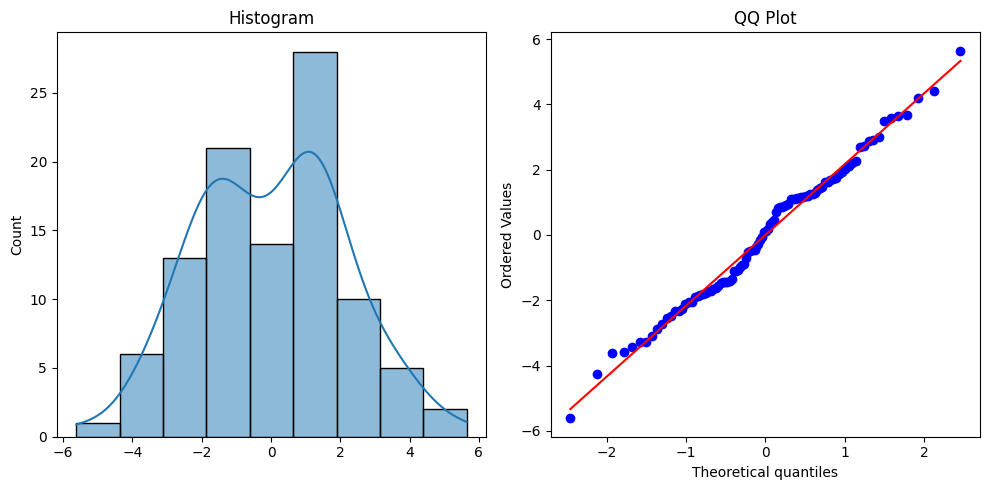

In [11]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

-> Histogram residual menunjukkan distribusi yang relatif simetris dan terpusat di sekitar nol. Pada QQ Plot, sebagian besar titik mengikuti garis diagonal, walaupun terdapat sedikit penyimpangan pada bagian ekor. Secara visual, residual dapat dikatakan cukup mendekati distribusi normal.

In [12]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9894883577655698, p-value = 0.6233677357995434


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

-> Berdasarkan histogram dan QQ Plot, residual terlihat cukup mendekati distribusi normal, dan hasil uji Shapiro-Wilk juga menunjukkan nilai p-value = 0,62337 > 0,05, sehingga $(H_0)$ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup bahwa residual tidak berdistribusi normal, sehingga kesimpulan dari uji Shapiro-Wilk konsisten dengan interpretasi berdasarkan plot.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [13]:
# Menentukan parameter simulasi
np.random.seed(1056)
n_periods = 120
beta_0, beta_1, beta_2= 50 + 56, 0.5*56, 0.02*56
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

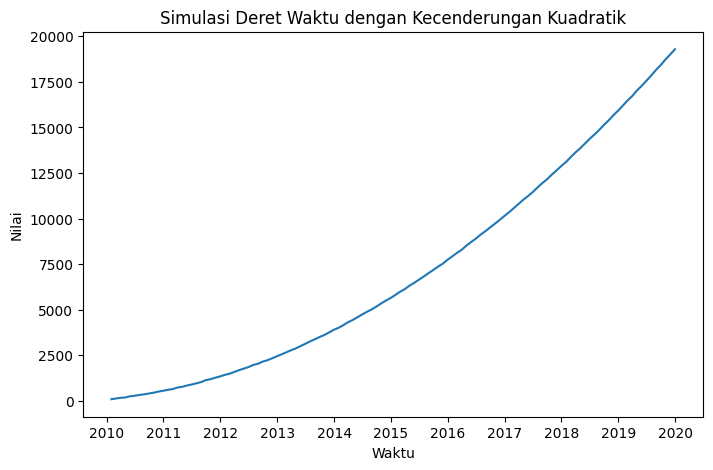

In [14]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

-> Deret menunjukkan kecenderungan meningkat dengan bentuk melengkung ke atas. Pada awal periode, kenaikan relatif lebih lambat, kemudian semakin lama nilai deret meningkat dengan laju yang semakin besar. Berbeda dengan kecenderungan linear yang memiliki laju perubahan relatif konstan, pada kecenderungan kuadratik laju perubahan meningkat seiring waktu. Oleh karena itu, pola yang dihasilkan berbentuk kurva, bukan garis lurus.

In [15]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.737e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.97e-321
Time:                        13:12:15   Log-Likelihood:                -452.29
No. Observations:                 120   AIC:                             910.6
Df Residuals:                     117   BIC:                             918.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        108.7568      2.861     38.016      0.0

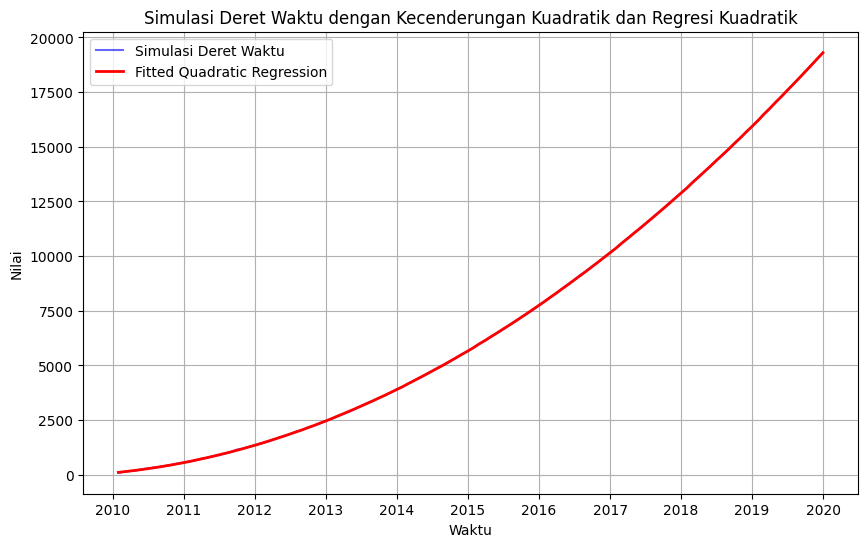

In [16]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

-> Koefisien hasil estimasi sangat dekat dengan parameter simulasi, yaitu $β_0​=108.7568$, $β_1=27.8465$, dan $β_2=1.1214$. Hal ini menunjukkan bahwa model berhasil menangkap bentuk kuadratik yang digunakan untuk membangkitkan data. Nilai $(R^2)$ yang sangat mendekati 1 menunjukkan bahwa komponen kuadratik menjelaskan hampir seluruh variasi data. Tetapi nilai tersebut sendiri tidak cukup untuk menyatakan model bebas dari overfitting. Dalam kasus ini, tingginya $(R^2)$ lebih masuk akal karena data memang sengaja dibangkitkan dari fungsi kuadratik dengan noise yang relatif kecil terhadap besarnya tren. Dari output yang tersedia, Durbin-Watson sebesar 1.973 cukup dekat dengan 2 dan Jarque-Bera memiliki p-value 0.565, sehingga tidak terdapat indikasi kuat masalah autokorelasi atau penyimpangan normalitas.

In [17]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [18]:
# Menentukan parameter simulasi
np.random.seed(1056)
n_periods = 120
beta0, beta1, beta2=50 + 56,-25*56, -2*56
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


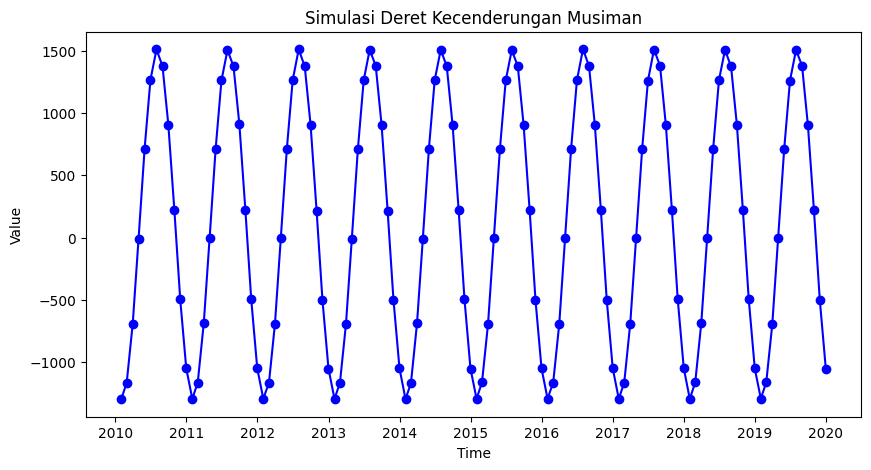

In [19]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

-> Deret menunjukkan pola naik-turun yang berulang setiap 12 periode. Pola tersebut memiliki bentuk yang relatif konsisten dari satu siklus ke siklus berikutnya.Karena satu siklus terdiri dari 12 periode, pola tersebut dapat dianggap sebagai pola musiman dengan periode 12. Tidak terdapat tren naik atau turun jangka panjang yang dominan, perubahan utama berasal dari komponen musiman dan noise acak.

In [20]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [21]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [23]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.293e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.91e-284
Time:                        13:13:11   Log-Likelihood:                -256.73
No. Observations:                 120   AIC:                             537.5
Df Residuals:                     108   BIC:                             570.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1293.9078      0.685  -1888.539      0.0

Bagaimana interpretasi dari hasil tersebut?

-> Karena model menggunakan dummy musiman tanpa intercept, masing-masing koefisien dapat diinterpretasikan sebagai estimasi nilai rata-rata deret untuk bulan tersebut. Jadi, berdasarkan hasil tersebut, nilai rata-rata tertinggi terjadi pada Juli, yaitu sekitar 1506.87, sedangkan nilai terendah terjadi pada Januari, yaitu sekitar −1293.91. Pola tersebut menunjukkan adanya variasi musiman yang sangat kuat sepanjang 12 bulan. Nilai meningkat dari Januari hingga mencapai maksimum sekitar Juli, kemudian kembali menurun hingga Desember. Nilai $(R^2)$ yang sangat mendekati 1 menunjukkan bahwa pola musiman tersebut mampu menjelaskan hampir seluruh variasi data simulasi. hal ini juga lebih make sense dikarenakan data memang dibangkitkan secara langsung dari komponen musiman + noise kecil.

In [24]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

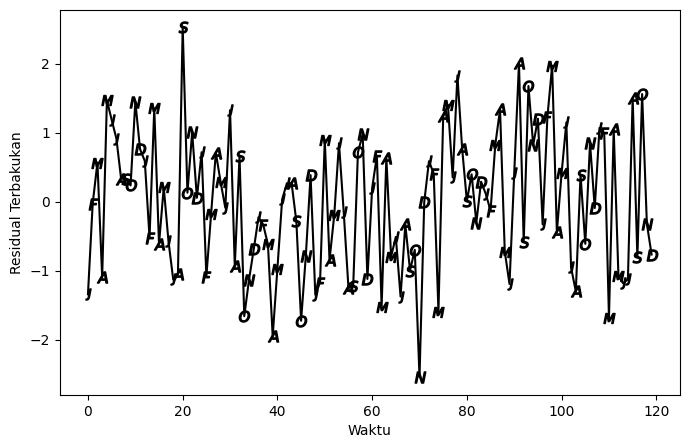

In [25]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


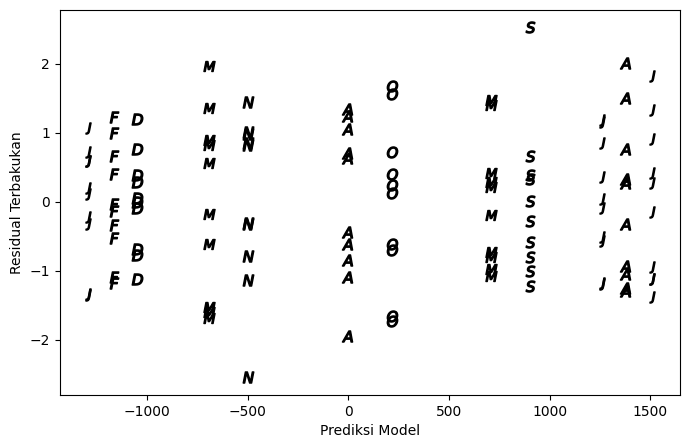

In [26]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

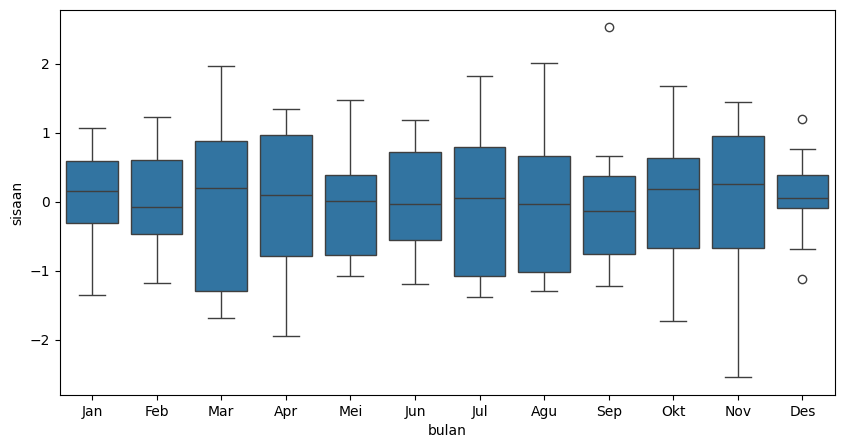

In [27]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

-> Pada plot residual terhadap waktu, residual berfluktuasi di sekitar nol dan tidak menunjukkan pola tren yang jelas. Pada plot residual terhadap nilai prediksi, residual juga tersebar di sekitar nol dan tidak terlihat pola sistematis yang kuat. Sementara itu, boxplot residual berdasarkan bulan menunjukkan bahwa residual pada masing-masing bulan umumnya berpusat di sekitar nol. Terdapat beberapa pencilan, tetapi tidak terlihat pola penyebaran yang menunjukkan masalah serius. Secara visual, model telah menangkap pola musiman utama sehingga residual yang tersisa relatif acak.

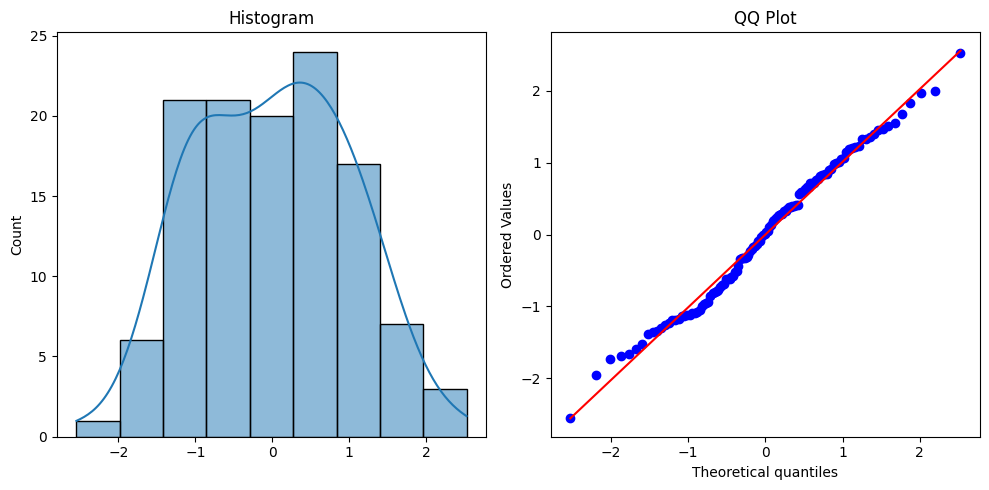

In [28]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

In [29]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [30]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [31]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.293e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.91e-284
Time:                        13:14:02   Log-Likelihood:                -256.73
No. Observations:                 120   AIC:                             537.5
Df Residuals:                     108   BIC:                             570.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1293.9078      0.685  -1888.539      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

-> Pada model dengan intercept, Januari menjadi kategori referensi. Oleh karena itu, intercept sebesar −1293.9078 merupakan estimasi rata-rata nilai deret pada bulan Januari. Koefisien bulan lainnya menunjukkan perbedaan rata-rata bulan tersebut terhadap Januari. penggunaan intercept, terletak pada setiap koefisien langsung yang merepresentasikan level/rata-rata masing-masing bulan. Sedangkan model tanpa intercept, dimaknai dengan Intercept merupakan level bulan referensi, yaitu Januari, sedangkan koefisien bulan lainnya merupakan selisih terhadap Januari. Kedua bentuk model pada dasarnya menghasilkan fitted value yang sama; yang berbeda adalah cara parameter direpresentasikan. Untuk asumsi regresi, output menunjukkan Durbin-Watson = 1.918, Jarque-Bera p-value = 0.344, dan Omnibus p-value = 0.163. Nilai Durbin-Watson cukup dekat dengan 2, sedangkan uji Jarque-Bera tidak memberikan bukti kuat adanya penyimpangan normalitas. Jadi, berdasarkan diagnostik yang tersedia, tidak terlihat indikasi kuat pelanggaran asumsi.

In [32]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [33]:
# Parameter
np.random.seed(1056)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 + 56, 10*56 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


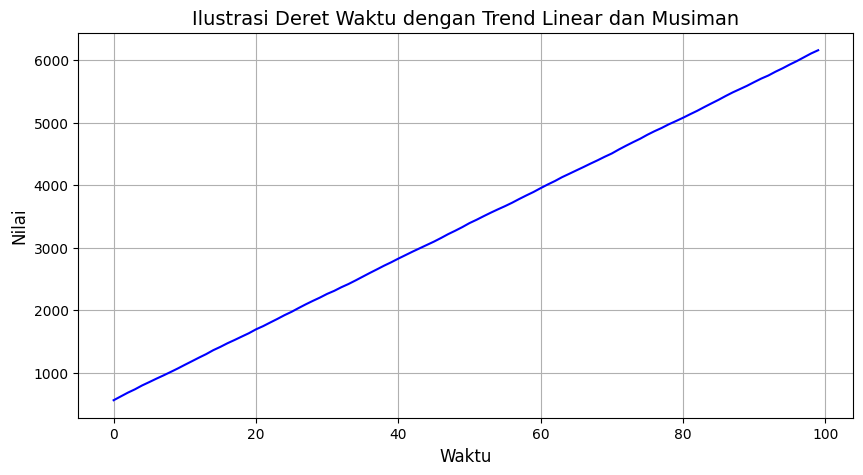

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [35]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [36]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [37]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.720e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.31e-247
Time:                        13:14:26   Log-Likelihood:                -212.27
No. Observations:                 100   AIC:                             450.5
Df Residuals:                      87   BIC:                             484.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      559.6103      0.808    692.911      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

-> Koefisien period sebesar 56.5050 menunjukkan adanya kecenderungan linear: setiap kenaikan satu periode dikaitkan dengan peningkatan nilai deret sekitar 56.505 satuan, dengan pola musiman diperhitungkan dalam model. Koefisien bulan menunjukkan perbedaan level awal untuk masing-masing bulan. Misalnya, koefisien Januari sebesar 559.6103 menunjukkan level dasar untuk Januari, sedangkan Februari sebesar 560.9168 menunjukkan level dasar Februari. Karena model tidak menggunakan intercept terpisah dan seluruh dummy bulan dimasukkan, setiap bulan memiliki nilai awalnya masing-masing, sementara kemiringan/tren sebesar 56.5050 digunakan bersama oleh seluruh bulan.

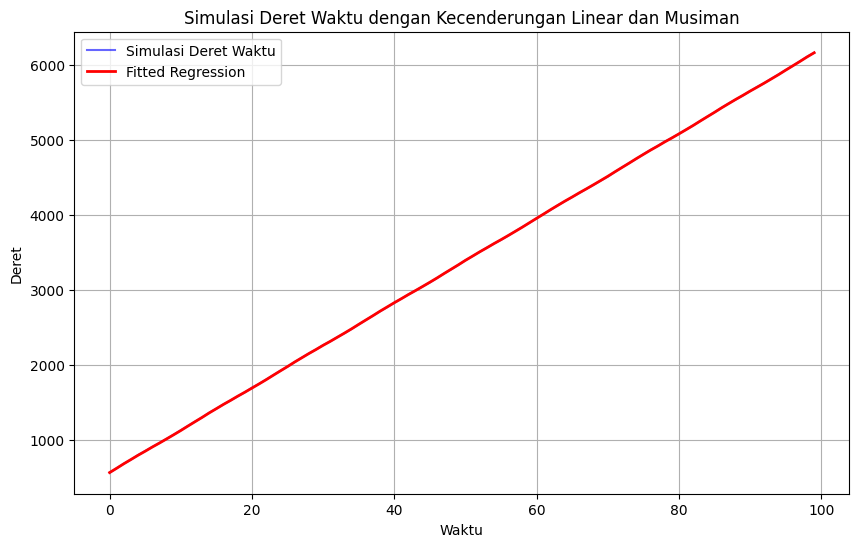

In [38]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

-> Berdasarkan diagnostik yang tersedia, nilai Durbin-Watson sebesar 1.777 masih cukup dekat dengan 2 sehingga tidak menunjukkan indikasi autokorelasi yang sangat kuat. Nilai Jarque-Bera sebesar p-value 0.604 dan Omnibus sebesar 0.577, keduanya lebih besar dari 0.05. Jadi tidak terdapat bukti yang cukup bahwa residual menyimpang dari distribusi normal. Dengan demikian, tidak terlihat pelanggaran asumsi yang serius berdasarkan diagnostik yang tersedia.

In [39]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [40]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

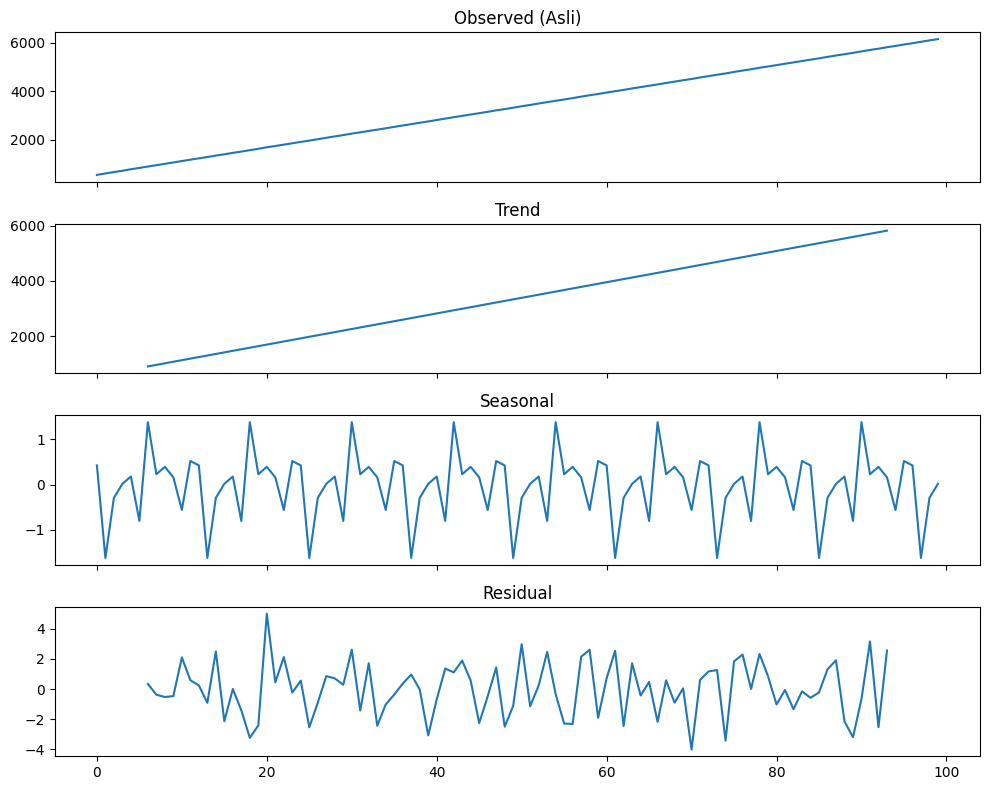

In [41]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

-> Hasil dekomposisi menunjukkan bahwa komponen utama deret adalah tren linear yang meningkat. Hal ini terlihat dari komponen Trend yang mengikuti pola kenaikan deret secara konsisten. Komponen Seasonal berfluktuasi di sekitar nol dan relatif kecil dibandingkan komponen tren. Artinya, tidak terdapat pola musiman yang dominan pada deret ini. Komponen Residual menunjukkan variasi acak yang tersisa setelah tren dan komponen musiman dipisahkan. Jadi, dekomposisi menunjukkan bahwa struktur utama deret berasal dari tren linear, sedangkan sisanya merupakan variasi musiman kecil dan noise.

In [42]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

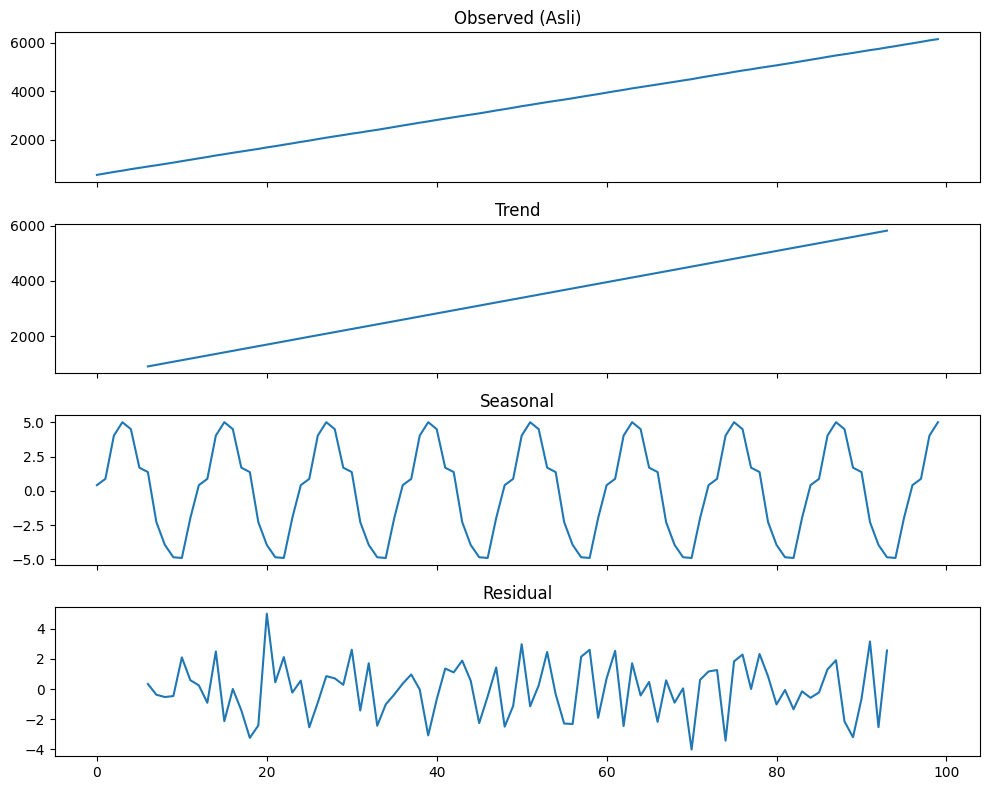

In [43]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

-> Hasil dekomposisi menunjukkan bahwa deret terdiri dari tiga komponen utama. Pertama, komponen Trend menunjukkan peningkatan yang hampir linear dari waktu ke waktu. Ini sesuai dengan adanya kecenderungan linear dalam data. Kedua, komponen Seasonal menunjukkan pola gelombang yang berulang secara teratur dengan periode 12. Ini menunjukkan adanya pola musiman yang konsisten. Ketiga, komponen Residual menunjukkan variasi acak yang tersisa setelah tren dan pola musiman dipisahkan.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [44]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1056)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 + 56, 10*56 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

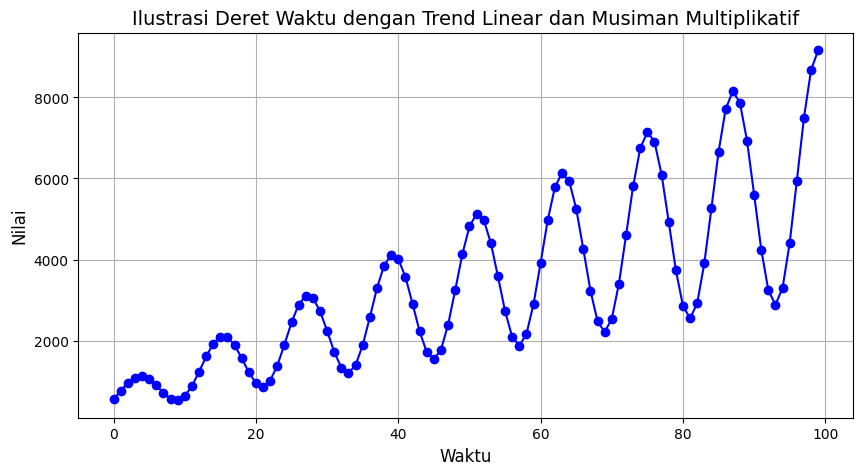

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [46]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

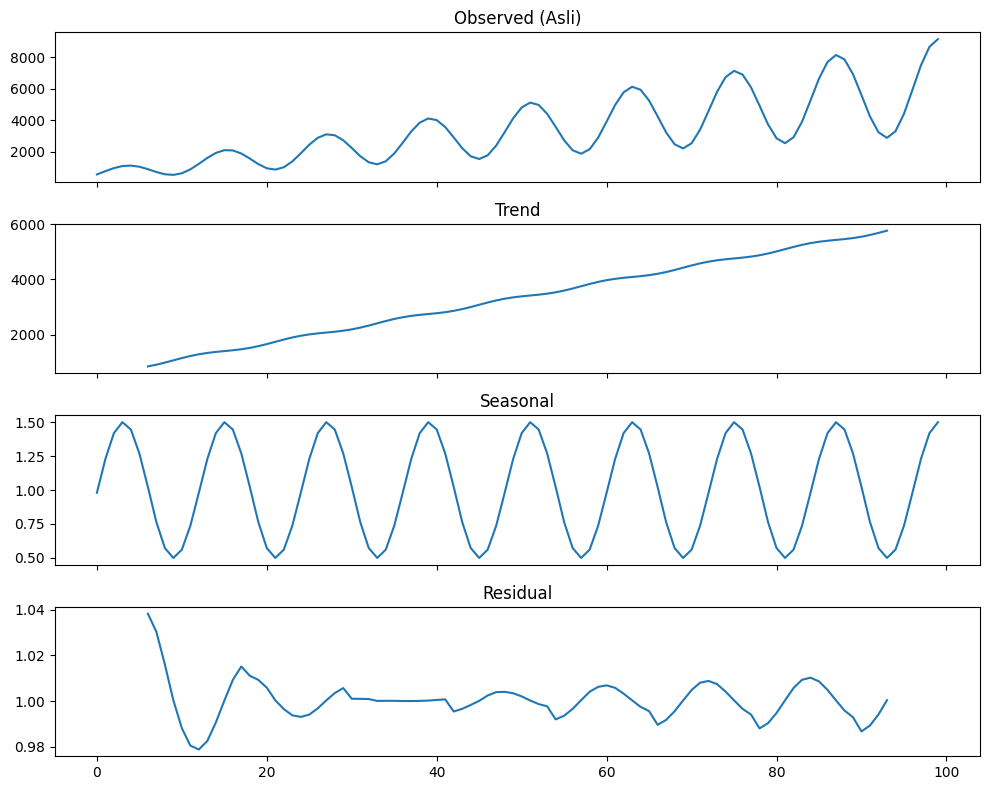

In [47]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

-> Pada deret multiplikatif terlihat adanya tren meningkat sekaligus pola musiman dengan amplitudo yang semakin besar ketika level deret meningkat. Komponen Trend menunjukkan peningkatan secara bertahap. Komponen Seasonal menunjukkan pola periodik yang relatif stabil dalam bentuk faktor pengali di sekitar 1. Karena besarnya fluktuasi musiman bergantung pada level tren, model multiplikatif lebih sesuai dibandingkan model aditif untuk pola seperti ini. Komponen Residual menunjukkan variasi yang tidak dijelaskan oleh tren dan pola musiman.

In [48]:
# Parameter
np.random.seed(1056)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

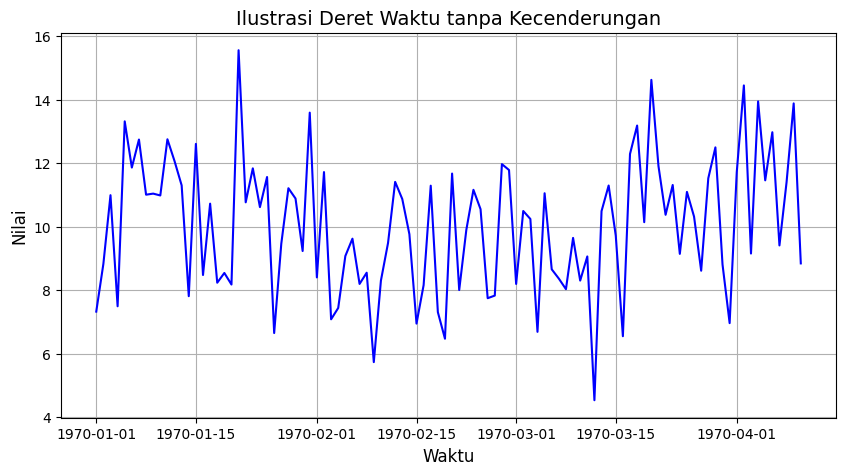

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

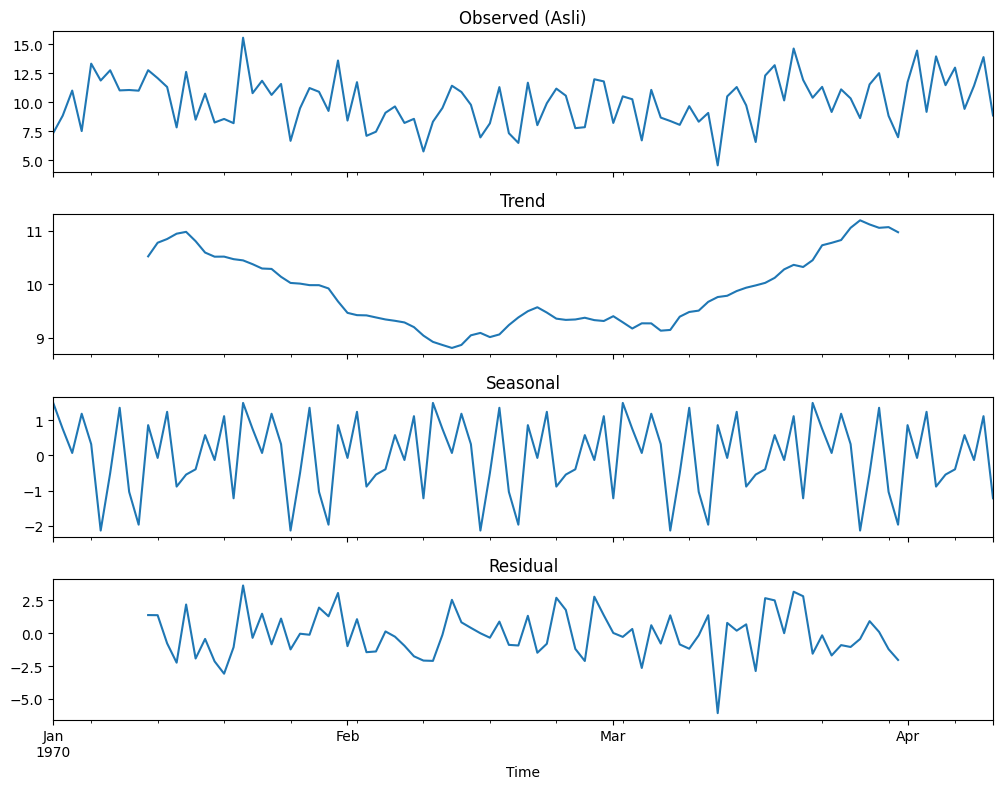

In [50]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

-> Deret observed menunjukkan fluktuasi acak di sekitar nilai rata-rata sekitar 10 dan tidak menunjukkan kecenderungan naik atau turun yang konsisten. Komponen Trend hasil dekomposisi memang mengalami sedikit pergerakan, tetapi tidak membentuk tren yang konsisten. Hal ini lebih tepat dipahami sebagai fluktuasi akibat proses penghalusan/dekomposisi, bukan sebagai bukti adanya tren sebenarnya. Komponen Seasonal juga tidak menunjukkan pola berulang yang jelas. Sebagian besar variasi justru terdapat pada komponen residual. Dengan demikian, karena data memang dibangkitkan hanya dari noise acak tanpa tren dan tanpa komponen musiman, hasil dekomposisi mendukung kesimpulan bahwa deret tersebut tidak memiliki struktur tren maupun musiman yang kuat.